In [62]:
!uv pip install kagglehub pandas matplotlib seaborn wordcloud nltk --quiet

In [63]:
# # IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# # THEN FEEL FREE TO DELETE THIS CELL.
# # NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# # ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# # NOTEBOOK.
# import kagglehub
# uciml_sms_spam_collection_dataset_path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')

# print('Data source import complete.')


In [64]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('./'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./sms_spam_detection.ipynb
./spam.csv


In [65]:
df = pd.read_csv(
    "spam.csv",
    encoding='latin1'
)

df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4958,ham,"What i mean was i left too early to check, cos...",NaN,NaN,NaN
5432,ham,Thanx a lot 4 ur help!,NaN,NaN,NaN
1199,ham,NEFT Transaction with reference number &lt;#&...,NaN,NaN,NaN
1091,ham,Please da call me any mistake from my side sor...,NaN,NaN,NaN
591,spam,You have been specially selected to receive a ...,NaN,NaN,NaN


In [66]:
df.shape

(5572, 5)

In [67]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [68]:
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [69]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [70]:
df['target'] = encoder.fit_transform(df['target'])

In [71]:
print(encoder.classes_)

mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))
print(mapping)

['ham' 'spam']
{'ham': 0, 'spam': 1}


In [72]:
df.sample(5)

,target,text
2296,1,<Forwarded from 21870000>Hi - this is your Mai...
3299,0,Just do what ever is easier for you
5076,0,"Guy, no flash me now. If you go call me, call ..."
3198,0,No de.am seeing in online shop so that i asked.
3372,0,Looks like you found something to do other tha...


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  5572 non-null   int64
 1   text    5572 non-null   str  
dtypes: int64(1), str(1)
memory usage: 87.2 KB


In [74]:
df.duplicated().sum()

np.int64(403)

In [75]:
df.drop_duplicates(keep='first', inplace=True)

In [76]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

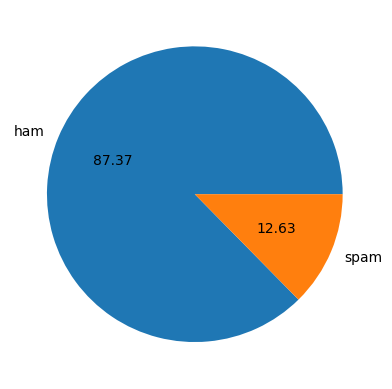

In [77]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(), labels=encoder.classes_, autopct="%0.2f")
plt.show()

In [78]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/kevin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [79]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [80]:
df.describe()

,target,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [81]:
df[df['target'] == 0].describe()

,target,num_characters,num_words,num_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [82]:
df[df['target'] == 1].describe()

,target,num_characters,num_words,num_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

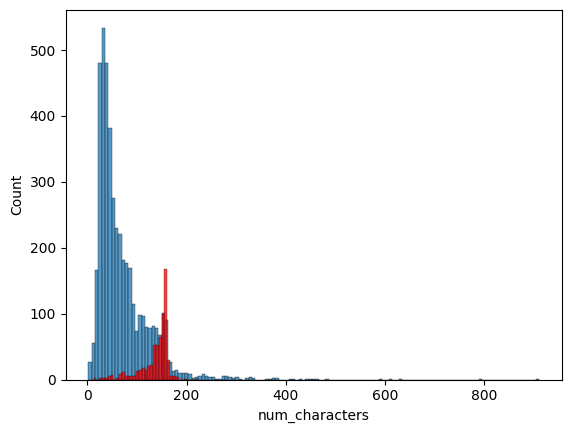

In [83]:
import seaborn as sns

sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

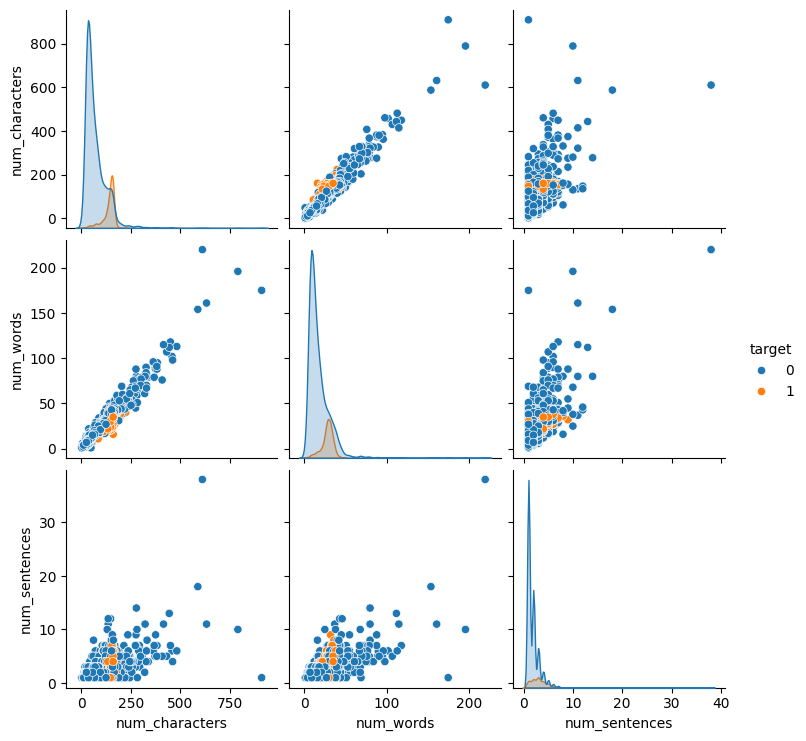

In [84]:
sns.pairplot(df, hue='target')

<Axes: >

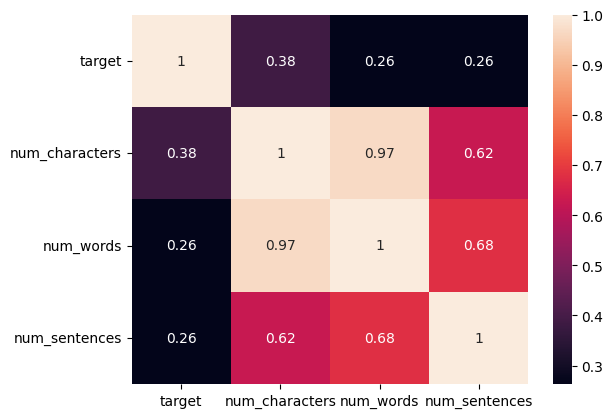

In [85]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

In [86]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

en_stopwords = stopwords.words('english')
en_punctuation = string.punctuation
ps = PorterStemmer()

In [87]:
def text_transform(text):

    tokens = nltk.word_tokenize(text.lower())

    transformed_text = [
        ps.stem(word)
        for word in tokens
        if word.isalnum()
        and word not in en_stopwords
        and word not in en_punctuation
    ]

    return " ".join(transformed_text)

In [88]:
text = 'Go until 20%% jurong point, crazy'
text_transform(text)

'go 20 jurong point crazi'

In [89]:
df['transformed_text'] = df['text'].apply(text_transform)

In [90]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=800, min_font_size=10, background_color='white')

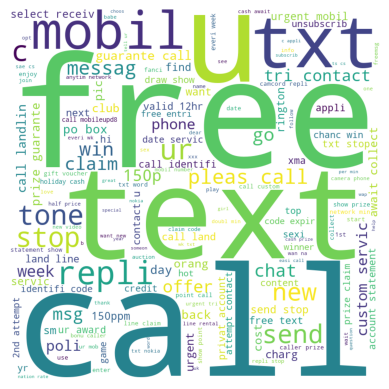

In [91]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

# Display using matplotlib
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

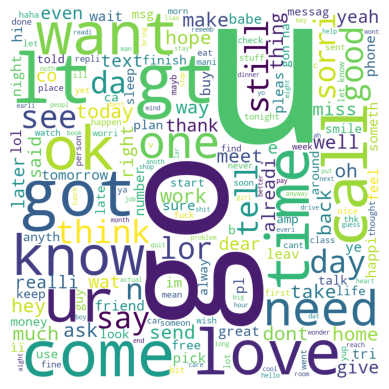

In [92]:
spam_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

# Display using matplotlib
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

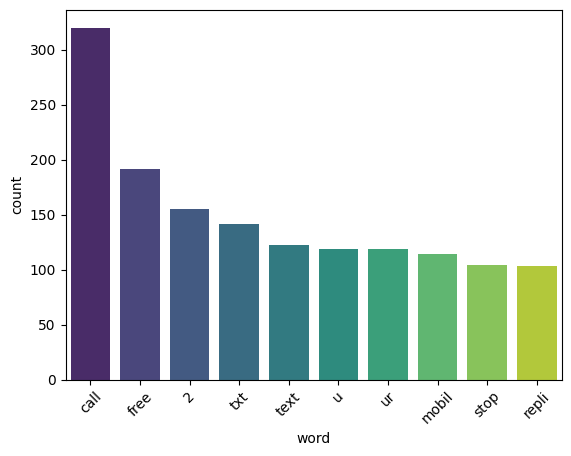

In [93]:
from collections import Counter

spam_corpus = []

for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

common_words = pd.DataFrame(
    Counter(spam_corpus).most_common(10)
)

common_words.columns = ['word', 'count']

sns.barplot(
    x='word',
    y='count',
    data=common_words,
    hue='word',
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)
plt.show()

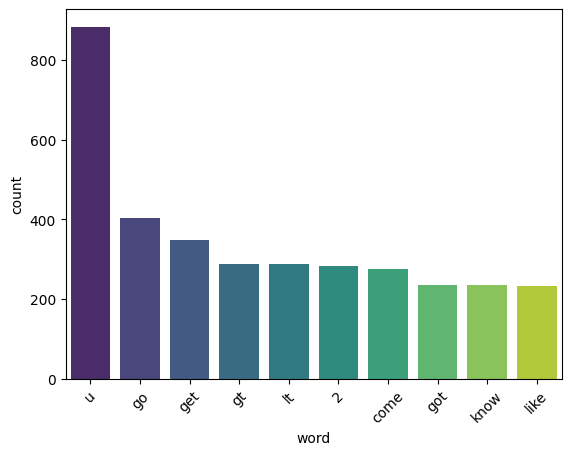

In [94]:
from collections import Counter

ham_corpus = []

for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

common_words = pd.DataFrame(
    Counter(ham_corpus).most_common(10)
)

common_words.columns = ['word', 'count']

sns.barplot(
    x='word',
    y='count',
    data=common_words,
    hue='word',
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)
plt.show()

In [105]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [95]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

In [96]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [97]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5169, 6708))

In [98]:
y = df['target'].values

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [101]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_gnb)}")
print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred_gnb)}")
print(f"Precision Score: {precision_score(y_test, y_pred_gnb)}")

Accuracy Score: 0.8684719535783365
Confusion Matrix: [[772 117]
 [ 19 126]]
Precision Score: 0.5185185185185185


In [102]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_mnb)}")
print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred_mnb)}")
print(f"Precision Score: {precision_score(y_test, y_pred_mnb)}")

Accuracy Score: 0.9738878143133463
Confusion Matrix: [[872  17]
 [ 10 135]]
Precision Score: 0.8881578947368421


In [103]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_bnb)}")
print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred_bnb)}")
print(f"Precision Score: {precision_score(y_test, y_pred_bnb)}")

Accuracy Score: 0.9661508704061895
Confusion Matrix: [[885   4]
 [ 31 114]]
Precision Score: 0.9661016949152542


In [104]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
